#### 1.Cài đặc mlxtend và nhập các gói thư viện 

In [27]:
import matplotlib.pyplot as plt
import mlxtend.frequent_patterns
import mlxtend.preprocessing
import numpy
import pandas

#### 2.Thực hiện một số tính toán để hiểu các khái niệm cơ bản như support, confident và lift

In [28]:
# danh sách các giao dịch mua hàng
example = [
['milk', 'bread', 'apples', 'cereal', 'jelly', 'cookies', 'salad', 'tomatoes'],
['beer', 'milk', 'chips', 'salsa', 'grapes', 'wine', 'potatoes', 'eggs', 'carrots'],
['diapers', 'baby formula', 'milk', 'bread', 'chicken', 'asparagus', 'cookies'],
['milk', 'cookies', 'chicken', 'asparagus', 'broccoli', 'cereal', 'orange juice'],
['steak', 'asparagus', 'broccoli', 'chips', 'salsa', 'ketchup', 'potatoes', 'salad'],
['beer', 'salsa', 'asparagus', 'wine', 'cheese', 'crackers', 'strawberries', 'cookies'],
['chocolate cake', 'strawberries', 'wine', 'cheese', 'beer', 'milk', 'orange juice'],
['chicken', 'peas', 'broccoli', 'milk', 'bread', 'eggs', 'potatoes', 'ketchup', 'crackers'],
['eggs', 'bread', 'cheese', 'turkey', 'salad', 'tomatoes', 'wine', 'steak', 'carrots'],
['bread', 'milk', 'tomatoes', 'cereal', 'chicken', 'turkey', 'chips', 'salsa', 'diapers']
]
# Tính support
# the number of transactions
N = len(example)
# the frequency of milk
f_x = sum(['milk' in i for i in example])
# the frequency of bread
f_y = sum(['bread' in i for i in example])
# the frequency of milk and bread
f_x_y = sum([
all(w in i for w in ['milk', 'bread'])
for i in example
])
# support (supp)
support = f_x_y / N
print("Support = {}".format(round(support, 4))) # support = 0.4
# confidence: x -> y
confidence = support / (f_x / N)
print("Confidence = {}".format(round(confidence, 4)))# Confidence = 0.5714
# lift: x -> y
lift = confidence / (f_y / N)
print("Lift = {}".format(round(lift, 4))) # Lift = 1.1429
# leverage: x -> y
leverage = support - ((f_x / N) * (f_y / N))
print("Leverage = {}".format(round(leverage, 4)))
# conviction: x -> y
conviction = (1 - (f_y / N)) / (1 - confidence)
print("Conviction = {}".format(round(conviction, 4)))

Support = 0.4
Confidence = 0.5714
Lift = 1.1429
Leverage = 0.05
Conviction = 1.1667


#### 3. Nạp dữ liệu, làm sạch dữ liệu và biến đổi dữ liệu về định dạng phù hợp để thực hiện xây dựng mô hình (chuyển dữ liệu từ 1 hóa đơn có nhiều dòng thành 1 hóa đơn chỉ có 1 dòng chứa các sản phẩm)

In [29]:
online = pandas.read_excel( io="Online Retail.xlsx",sheet_name="Online Retail",header=0 , engine="openpyxl")
# create new column called IsCPresent
online['IsCPresent'] = ( # looking for C in InvoiceNo column
    online['InvoiceNo'] # convert column to string type for the apply function below
    .astype(str)
    .apply(lambda x: 1 if x.find('C') != -1 else 0))


online1 = (
    online # filter out non-positive quantity values
    .loc[online["Quantity"] > 0] # remove InvoiceNos starting with C
    .loc[online['IsCPresent'] != 1] # column filtering
    .loc[:, ["InvoiceNo", "Description"]]# dropping all rows with at least one missing value
    .dropna()
) 
# extract unique invoice numbers as list
invoice_no_list = online1.InvoiceNo.tolist()
invoice_no_list = list(set(invoice_no_list))
print("Length of list of invoice numbers:{ln}".format(ln=len(invoice_no_list)))
# get 5000 transaction
subset_invoice_no_list = invoice_no_list[0:5000]
# filter data set down to based on subset of invoice number list
online1 = online1.loc[online1["InvoiceNo"].isin(subset_invoice_no_list)]
invoice_item_list = []
for num in list(set(online1.InvoiceNo.tolist())):
    # filter data set down to one invoice number
    tmp_df = online1.loc[online1['InvoiceNo'] == num]
    # extract item descriptions and convert to list
    tmp_items = tmp_df.Description.tolist()
    # append list invoice_item_list
    invoice_item_list.append(tmp_items)
print(invoice_item_list[1:5])

Length of list of invoice numbers:20136
[['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT'], ['ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM ", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY ', 'BOX OF 6 ASSORTED COLOUR TEASPOONS', 'BOX OF VINTAGE JIGSAW BLOCKS ', 'BOX OF VINTAGE ALPHABET BLOCKS', 'HOME BUILDING BLOCK WORD', 'LOVE BUILDING BLOCK WORD', 'RECIPE BOX WITH METAL HEART', 'DOORMAT NEW ENGLAND'], ['JAM MAKING SET WITH JARS', 'RED COAT RACK PARIS FASHION', 'YELLOW COAT RACK PARIS FASHION', 'BLUE COAT RACK PARIS FASHION'], ['BATH BUILDING BLOCK WORD']]


#### 4. Mã hóa dữ liệu về dạng dữ liệu mà giải thuật apriori trong gói mlxtend yêu cầu

In [30]:
online_encoder = mlxtend.preprocessing.TransactionEncoder()
online_encoder_array = online_encoder.fit_transform(invoice_item_list)
online_encoder_df = pandas.DataFrame(
    online_encoder_array,
    columns=online_encoder.columns_
)
# this is a very big table, so for more easy viewing only a subset is printed

print("Data dimension (row count, col count):{dim}".format(dim=online_encoder_df.shape))
online_encoder_df.loc[4970:4979, online_encoder_df.columns.tolist()[0:8]]


Data dimension (row count, col count):(5000, 3136)


,4 PURPLE FLOCK DINNER CANDLES,OVAL WALL MIRROR DIAMANTE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS
4970,False,False,False,False,False,False,False,False
4971,False,False,False,False,False,False,False,False
4972,False,False,False,False,False,False,False,False
4973,False,False,False,False,False,False,False,False
4974,False,False,True,False,False,False,False,False
4975,False,False,False,False,False,False,False,False
4976,False,False,False,False,False,False,False,False
4977,False,False,False,False,False,False,False,False
4978,False,False,False,False,False,False,False,False
4979,False,False,False,False,False,False,False,False


#### 5. Trích các luật có trong tập phổ biến đã thực hiện ở bước 1

In [31]:
# case 1: hiển thị 6 luật trong 1064 luật được tìm thấy
rules = mlxtend.frequent_patterns.association_rules(
    mod_colnames_minsupport,
    metric="confidence",
    min_threshold=0.6,
    support_only=False
)
rules.loc[0:6]
# case 2: liệt kê các rule thỏa mãn điều kiện min_threshold
rules2 = mlxtend.frequent_patterns.association_rules(
    mod_colnames_minsupport,
    metric="lift", #có thể sử dụng support, confidence, ...
    min_threshold=50,
    support_only=False
)
print("Number of Associations: {}".format(rules2.shape[0])) # 170 luật
rules2.loc[0:6]

Number of Associations: 170


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(BEADED CRYSTAL HEART GREEN ON STICK),(BEADED CRYSTAL HEART PINK ON STICK),0.0126,0.0156,0.0108,0.857143,54.945055,1.0,0.010603,6.890800,0.994329,0.620690,0.854879,0.774725
1,(BEADED CRYSTAL HEART PINK ON STICK),(BEADED CRYSTAL HEART GREEN ON STICK),0.0156,0.0126,0.0108,0.692308,54.945055,1.0,0.010603,3.209050,0.997359,0.620690,0.688381,0.774725
2,(CHRISTMAS TREE DECORATION WITH BELL),(CHRISTMAS TREE HEART DECORATION),0.0140,0.0140,0.0120,0.857143,61.224490,1.0,0.011804,6.902000,0.997634,0.750000,0.855114,0.857143
3,(CHRISTMAS TREE HEART DECORATION),(CHRISTMAS TREE DECORATION WITH BELL),0.0140,0.0140,0.0120,0.857143,61.224490,1.0,0.011804,6.902000,0.997634,0.750000,0.855114,0.857143
4,(CHRISTMAS TREE STAR DECORATION),(CHRISTMAS TREE DECORATION WITH BELL),0.0140,0.0140,0.0120,0.857143,61.224490,1.0,0.011804,6.902000,0.997634,0.750000,0.855114,0.857143
5,(CHRISTMAS TREE DECORATION WITH BELL),(CHRISTMAS TREE STAR DECORATION),0.0140,0.0140,0.0120,0.857143,61.224490,1.0,0.011804,6.902000,0.997634,0.750000,0.855114,0.857143
6,(CHRISTMAS TREE STAR DECORATION),(CHRISTMAS TREE HEART DECORATION),0.0140,0.0140,0.0122,0.871429,62.244898,1.0,0.012004,7.668889,0.997905,0.772152,0.869603,0.871429


#### 6. Hình vẽ cho thấy mối quan hệ giữa support, confidence của luật

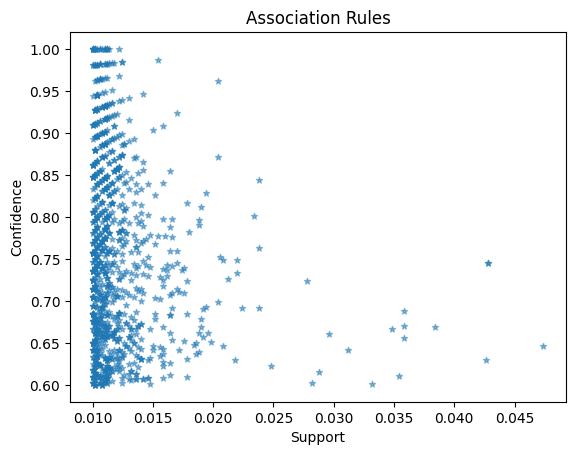

In [32]:
rules.plot.scatter("support", "confidence", alpha=0.5, marker="*")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()

#### 7. Hình vẽ cho thấy mối quan hệ giữa số item và confidence của luật

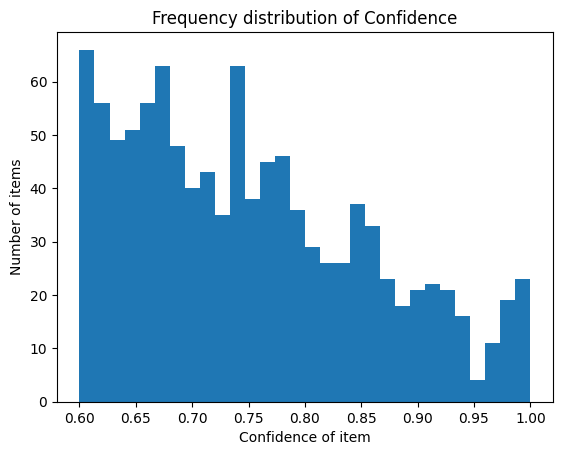

In [33]:
rules.hist("confidence", grid=False, bins=30)
plt.xlabel("Confidence of item")
plt.ylabel("Number of items")
plt.title("Frequency distribution of Confidence")
plt.show()


### Kết thúc 